In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = {
    "Topic": [
        "Big Data (Spark / Hadoop)", "Data Analysis / Statistics", "Data Journalism",
        "Data Visualization", "Deep Learning", "Machine Learning"
    ],
    "Very Interested": [1332, 1688, 429, 1340, 1263, 1629],
    "Somewhat Interested": [729, 444, 1081, 734, 770, 477],
    "Not Interested": [127, 60, 610, 102, 136, 74]
}

df = pd.DataFrame(data)

In [3]:
df.head()

,Topic,Very Interested,Somewhat Interested,Not Interested
0,Big Data (Spark / Hadoop),1332,729,127
1,Data Analysis / Statistics,1688,444,60
2,Data Journalism,429,1081,610
3,Data Visualization,1340,734,102
4,Deep Learning,1263,770,136


### Task 1:
Sort the dataset in descending order by the "Very interested" column, convert values to percentages (rounded to 2
decimal places), and create a Matplotlib bar chart for it.

In [5]:
df_sorted = df.sort_values(by="Very Interested", ascending=False)
total_responses = 2233


In [7]:
df_sorted.iloc[:, 1:] = df_sorted.iloc[:, 1:].astype(float).apply(lambda x: round((x / total_responses) * 100, 2))

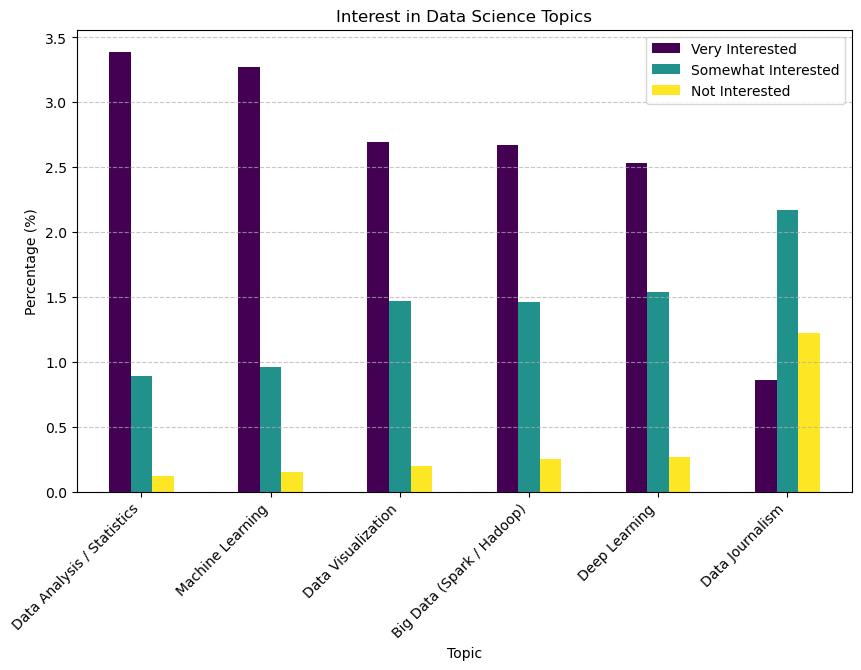

In [8]:
df_sorted.plot(x="Topic", kind="bar", stacked=False, figsize=(10, 6), colormap='viridis')
plt.title("Interest in Data Science Topics")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Task 2:
Using the given dataset on interest in various data-related topics, determine the probability that a randomly selected
response falls into the "Very interested" category for any topic greater than 1400 responses.

In [24]:
prob = df[df["Very Interested"] > 1400]["Very Interested"].sum() / df["Very Interested"].sum()
print("Probability of a randomly selected response falling\ninto 'Very Interested' for topics >1400:", round(prob, 2))

Probability of a randomly selected response falling
into 'Very Interested' for topics >1400: 0.43


### Task 3:
Visualize the relationship between “Very interested”, “Somewhat interested”, and “Not interested”.

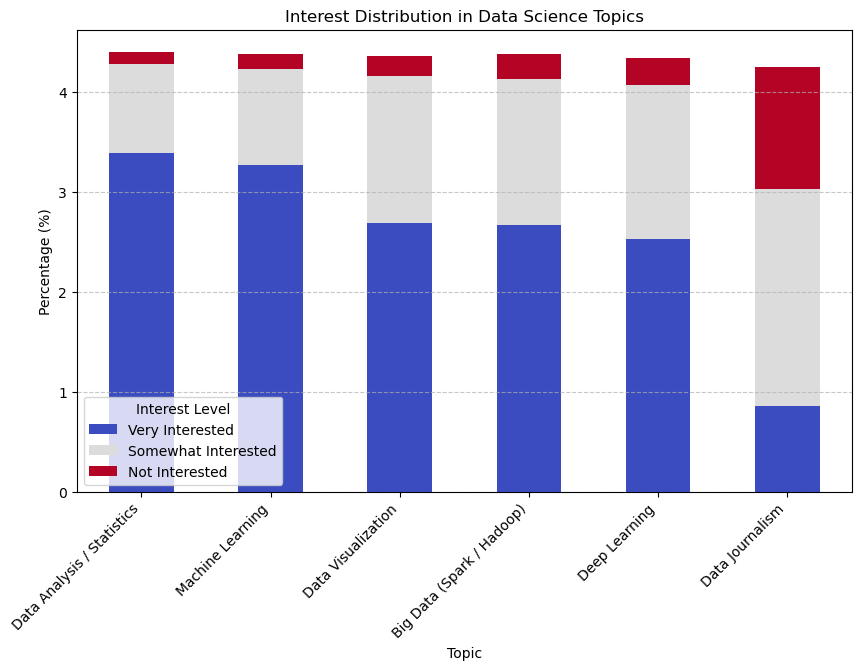

In [10]:
df_sorted.plot(x="Topic", kind="bar", stacked=True, figsize=(10, 6), colormap='coolwarm')
plt.title("Interest Distribution in Data Science Topics")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Interest Level")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Task 4:
Suppose we have to add these three rows in this dataset and make a code to identify the missing values in the
dataset. Suggest how to handle these missing values.

In [11]:
new_data = {
    "Topic": ["Machine Learning", "Artificial Intelligence (AI)", "Cloud Computing"],
    "Very Interested": [2000, 1500, 1300],
    "Somewhat Interested": [None, 600, 900],
    "Not Interested": [100, 200, None]
}

In [12]:
df_new = pd.DataFrame(new_data)
df_combined = pd.concat([df, df_new], ignore_index=True)

In [13]:
print("Missing Values in Dataset:")
print(df_combined.isnull().sum())

Missing Values in Dataset:
Topic                  0
Very Interested        0
Somewhat Interested    1
Not Interested         1
dtype: int64


In [14]:
df_combined.fillna(df_combined.mean(numeric_only=True), inplace=True)
print("\nAfter Handling Missing Values:")
print(df_combined)


After Handling Missing Values:
                          Topic  Very Interested  Somewhat Interested  \
0     Big Data (Spark / Hadoop)             1332              729.000   
1    Data Analysis / Statistics             1688              444.000   
2               Data Journalism              429             1081.000   
3            Data Visualization             1340              734.000   
4                 Deep Learning             1263              770.000   
5              Machine Learning             1629              477.000   
6              Machine Learning             2000              716.875   
7  Artificial Intelligence (AI)             1500              600.000   
8               Cloud Computing             1300              900.000   

   Not Interested  
0         127.000  
1          60.000  
2         610.000  
3         102.000  
4         136.000  
5          74.000  
6         100.000  
7         200.000  
8         176.125  


### Task 5:
Export the final cleaned DataFrame to a CSV file named "interest_analysis.csv".

In [15]:
df_combined.to_csv("interest_analysis.csv", index=False)
print("\nDataset saved as 'interest_analysis.csv'")


Dataset saved as 'interest_analysis.csv'


### Task 6:
Compare AI, Machine Learning, and Cloud Computing. Which field has the most balanced interest levels?

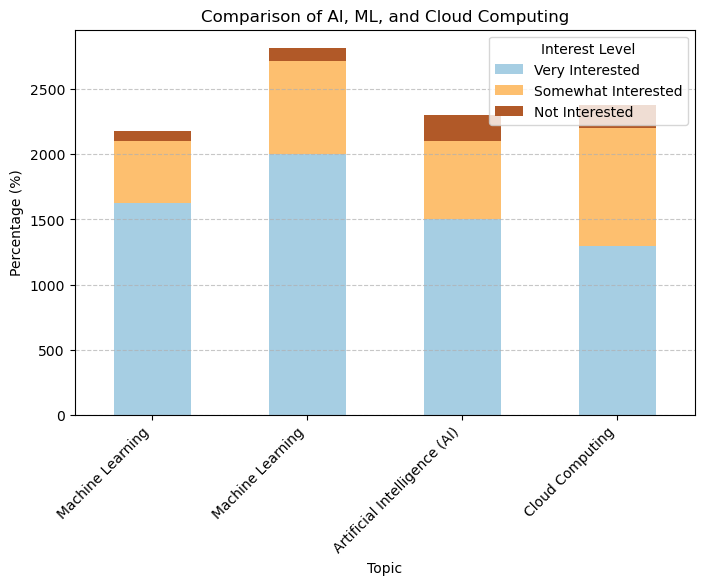

In [17]:
ai_ml_cc = df_combined[df_combined['Topic'].isin(["Artificial Intelligence (AI)", "Machine Learning", "Cloud Computing"])]
ai_ml_cc.plot(x="Topic", kind="bar", stacked=True, figsize=(8, 5), colormap='Paired')
plt.title("Comparison of AI, ML, and Cloud Computing")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Interest Level")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()